<a href="https://colab.research.google.com/github/PaulHoeft/IT480-FA26/blob/main/Assignments/Assignment%202/Assignment2_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *(replace with your name)*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [2]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Deadku
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:10<00:00, 40.1MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [3]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

{'fire_images': 755, 'non_fire_images': 244}


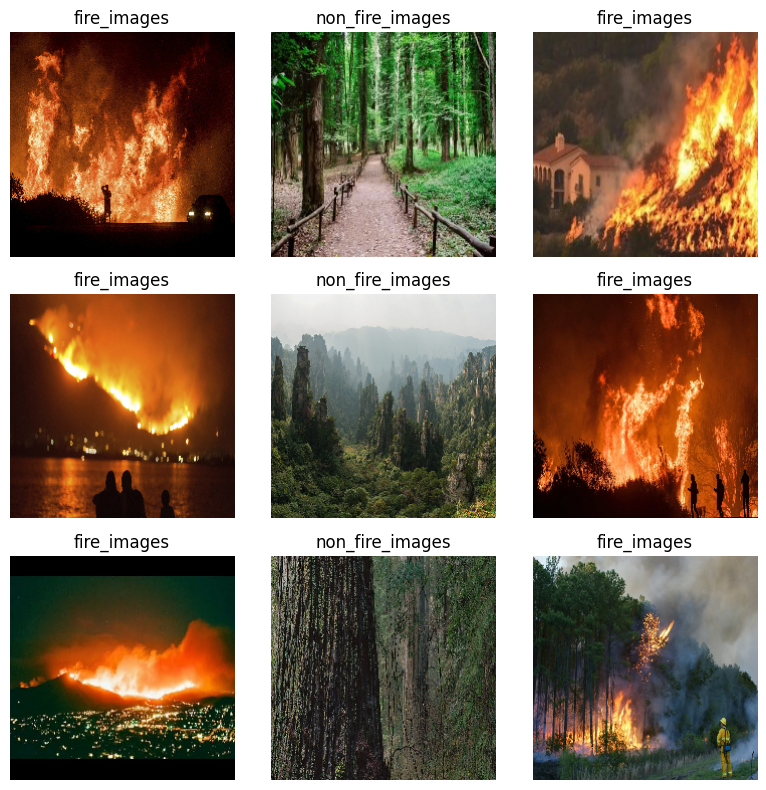

In [4]:
# Your exploration here

fire_counts = {}

for name in class_names_fire:
    folder = os.path.join(data_dir_fire, name)
    fire_counts[name] = len(os.listdir(folder))

print(fire_counts)

plt.figure(figsize=(8, 8))

for images, labels in train_raw_fire.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names_fire[labels[i].numpy()])
        plt.axis("off")

plt.tight_layout()
plt.show()

*What did you notice about this dataset? Does it change how you'll approach the next steps?*

first thing I noticed was that the dataset is not balanced. There are 755 fire images and 244 non-fire images, so there are a lot more examples of fire. because of that, I do not think accuracy alone will tell me how well the model is doing. I will also look at the confusion matrix to see if it is having more trouble with one class than the other.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [5]:
# Preprocess the data here

AUTOTUNE = tf.data.AUTOTUNE

def prepare_data(dataset):
    return dataset.map(
        lambda images, labels: (
            preprocess_input(tf.cast(images, tf.float32)),
            labels
        ),
        num_parallel_calls=AUTOTUNE
    ).prefetch(AUTOTUNE)

train_fire = prepare_data(train_raw_fire)
val_fire = prepare_data(val_raw_fire)
test_fire = prepare_data(test_raw_fire)

In [6]:
# Build your model here

base_fire = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_fire.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_fire(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(1, activation="sigmoid")(x)

model_fire = Model(inputs, outputs)

model_fire.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# Compile your model here

model_fire.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 1D — Train and Evaluate

In [8]:
# Train your model here

history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=5
)

Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.6886 - loss: 0.5767 - val_accuracy: 0.8273 - val_loss: 0.3731
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9271 - loss: 0.2124 - val_accuracy: 0.9281 - val_loss: 0.1859
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9600 - loss: 0.1318 - val_accuracy: 0.9496 - val_loss: 0.1414
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9743 - loss: 0.1032 - val_accuracy: 0.9856 - val_loss: 0.0958
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9786 - loss: 0.0873 - val_accuracy: 0.9856 - val_loss: 0.0826


In [9]:
# Report validation and test accuracy here

val_loss_fire, val_acc_fire = model_fire.evaluate(val_fire, verbose=0)
test_loss_fire, test_acc_fire = model_fire.evaluate(test_fire, verbose=0)

print("Validation Accuracy:", val_acc_fire)
print("Test Accuracy:", test_acc_fire)

Validation Accuracy: 0.971222996711731
Test Accuracy: 0.96875


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

a false negative would be more costly because that would mean the model missed an actual fire. In the test results, only 1 fire image was incorrectly predicted as non fire, while 5 non-fire images were predicted as fire. I would rather have a few more false alarms than miss an actual fire. Because non-fire is class 1 in this dataset, I could raise the threshold needed to predict non-fire so the model is more likely to treat uncertain images as fire.

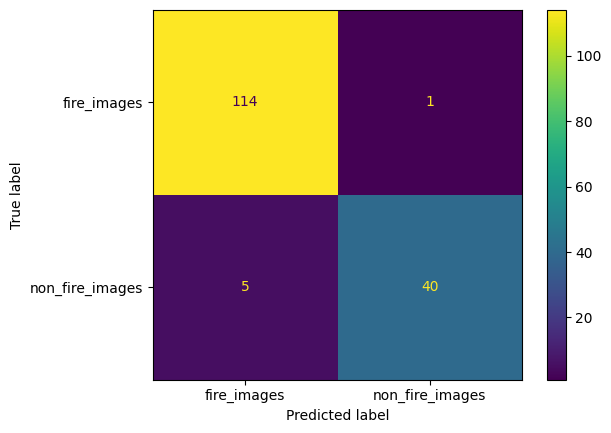

In [10]:
# Build your confusion matrix here

y_true_fire = []
y_pred_fire = []

for images, labels in test_fire:
    predictions = model_fire.predict(images, verbose=0).ravel()
    predictions = (predictions >= 0.5).astype(int)

    y_true_fire.extend(labels.numpy())
    y_pred_fire.extend(predictions)

cm_fire = confusion_matrix(y_true_fire, y_pred_fire)

disp_fire = ConfusionMatrixDisplay(
    confusion_matrix=cm_fire,
    display_labels=class_names_fire
)

disp_fire.plot()
plt.show()

*Your answer:*
missing an actual fire would be worse than having a false alarm. A false alarm would be annoying, but missing a real fire could put people or property in danger. Since the model uses non fire as class 1, I would want it to be more confident before deciding that an image is safe. I could raise the threshold for predicting non fire so uncertain images are more likely to be treated as a possible fire.



---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [11]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['PermanentCrop', 'Highway', 'Industrial', 'River', 'AnnualCrop', 'Pasture', 'HerbaceousVegetation', 'Residential', 'Forest', 'SeaLake']


In [12]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [13]:
# Preprocess the data here

train_sat = prepare_data(train_raw_sat)
val_sat = prepare_data(val_raw_sat)
test_sat = prepare_data(test_raw_sat)

In [14]:
# Build your model here

base_sat = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(len(class_names_sat), activation="softmax")(x)

model_sat = Model(inputs, outputs)

model_sat.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# Compile your model here
model_sat.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 2C — Train and Evaluate

In [16]:
# Train your model here

history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=5
)

Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1094s 2s/step - accuracy: 0.8783 - loss: 0.3723 - val_accuracy: 0.9336 - val_loss: 0.2159
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1209s 2s/step - accuracy: 0.9343 - loss: 0.1956 - val_accuracy: 0.9390 - val_loss: 0.1897
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1112s 2s/step - accuracy: 0.9470 - loss: 0.1597 - val_accuracy: 0.9388 - val_loss: 0.1843
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1136s 2s/step - accuracy: 0.9527 - loss: 0.1392 - val_accuracy: 0.9390 - val_loss: 0.1811
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 1091s 2s/step - accuracy: 0.9601 - loss: 0.1224 - val_accuracy: 0.9398 - val_loss: 0.1766


In [17]:
# Report validation and test accuracy here
val_loss_sat, val_acc_sat = model_sat.evaluate(val_sat, verbose=0)
test_loss_sat, test_acc_sat = model_sat.evaluate(test_sat, verbose=0)

print("Validation Accuracy:", val_acc_sat)
print("Test Accuracy:", test_acc_sat)


Validation Accuracy: 0.9385530352592468
Test Accuracy: 0.9362697005271912


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

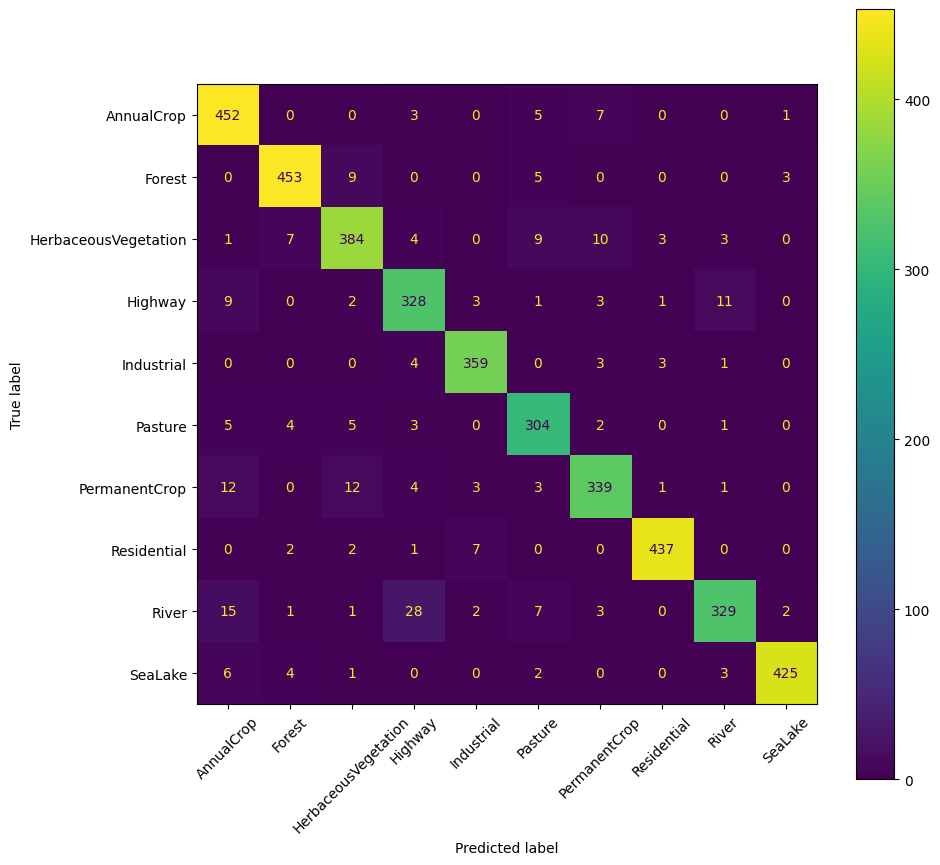

In [19]:
# Build your confusion matrix here

y_true_sat = []
y_pred_sat = []

for images, labels in test_sat:
    predictions = model_sat.predict(images, verbose=0)
    predictions = np.argmax(predictions, axis=1)

    y_true_sat.extend(labels.numpy())
    y_pred_sat.extend(predictions)

cm_sat = confusion_matrix(y_true_sat, y_pred_sat)

fig, ax = plt.subplots(figsize=(10, 10))

disp_sat = ConfusionMatrixDisplay(
    confusion_matrix=cm_sat,
    display_labels=class_names_sat
)

disp_sat.plot(ax=ax, xticks_rotation=45)
plt.show()

In [20]:
mistakes = []

for i in range(len(class_names_sat)):
    for j in range(len(class_names_sat)):
        if i != j:
            mistakes.append(
                (cm_sat[i, j], class_names_sat[i], class_names_sat[j])
            )

mistakes.sort(reverse=True)

for count, actual, predicted in mistakes[:5]:
    print(actual, "was predicted as", predicted, count, "times")

River was predicted as Highway 28 times
River was predicted as AnnualCrop 15 times
PermanentCrop was predicted as HerbaceousVegetation 12 times
PermanentCrop was predicted as AnnualCrop 12 times
Highway was predicted as River 11 times


*Your answer:*

The biggest confusion was between River and Highway, with 28 River images being predicted as Highway. There were also some mistakes between PermanentCrop, AnnualCrop, and HerbaceousVegetation. This makes sense to me because rivers and highways can both look like long narrow lines from above, while the different crop and vegetation classes can have similar colors and patterns.


---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy |97.12% |93.86% |
| Test Accuracy |96.88% |93.75% |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.

the fire dataset is the closer match to ImageNet because the fire images are more like normal photographs taken from the ground. EuroSAT is a bigger mismatch because the images are satellite pictures taken from above. The Fire model had a test accuracy of 96.88%, while the EuroSAT model had a test accuracy of 93.75%. Both models still performed well, but the Fire model did a little better, which could be because those images are more similar to the type of images MobileNetV2 originally trained on.


2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

both models could probably improve if some of the pretrained layers were allowed to change. I would expect this to help EuroSAT more because satellite images are much different from normal ImageNet pictures. Fine tuning some of the later layers could help the model learn features that are more useful for identifying things like crops, rivers, and highways. The Fire dataset already matches normal photographs better, so the frozen features seem to work really well for it already.

*Your answers:*




---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.

*Your answers:*

The Fire dataset was unbalanced because it had 755 fire images and only 244 non fire images, so I also looked at the confusion matrix instead of only relying on accuracy. In Part 1 I used one output with sigmoid and binary crossentropy because there were only two classes, while Part 2 used ten outputs with softmax and sparse categorical crossentropy because EuroSAT had ten classes. The Fire model had a test accuracy of 96.88%, while the EuroSAT model had a test accuracy of 93.75%. This showed me that a pretrained model's usefulness depends on both the model itself and how similar the new dataset is to what it originally trained on. The Fire images were closer to regular ImageNet pictures, and that model ended up performing a little better than the satellite model.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.